# 03 — Evaluation
Run inference and compute metrics for any model (baseline or LoRA) using `scripts/eval.py` and `scripts/metrics.py`.
Change `MODEL_KEY` and `MODE` to evaluate a different model.

In [ ]:
import os
import sys
import pathlib

IN_COLAB = 'google.colab' in str(get_ipython())

PACE_PROJECT_ROOT = '/home/hice1/arios35/scratch/slm_logic_hardening'

if IN_COLAB:
    from google.colab import drive, userdata
    drive.mount('/content/drive', force_remount=True)
    OUTPUT_BASE = '/content/drive/MyDrive/slm_logic_hardening/outputs'
    os.chdir('/content/drive/MyDrive/slm_logic_hardening')
    sys.path.insert(0, '/content/drive/MyDrive/slm_logic_hardening')
    import subprocess
    subprocess.run(['pip', 'install', '-q', 'transformers', 'datasets', 'pyyaml', 'sentencepiece', 'peft', 'accelerate'])
    from huggingface_hub import login
    login(token=userdata.get('HF_TOKEN'))
else:
    # PACE-ICE or local
    if os.path.exists(PACE_PROJECT_ROOT):
        project_root = pathlib.Path(PACE_PROJECT_ROOT)
    else:
        project_root = pathlib.Path().resolve()
        if not (project_root / 'scripts').exists():
            project_root = project_root.parent
    os.chdir(str(project_root))
    sys.path.insert(0, str(project_root))
    OUTPUT_BASE = str(project_root / 'outputs')

    # HF token — from env var or prompt
    hf_token = os.environ.get('HF_TOKEN')
    if not hf_token:
        import getpass
        hf_token = getpass.getpass('Enter HF token: ')
    from huggingface_hub import login
    login(token=hf_token)

print(f'Working dir: {os.getcwd()}')
print(f'Output base: {OUTPUT_BASE}')

In [ ]:
import torch
device = 'mps' if torch.backends.mps.is_available() else \
         'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')

Device: cuda


## Configuration — change here to switch model

In [ ]:
from pathlib import Path

MODEL_KEY    = 'phi35'       # 'phi35' | 'llama8b' | 'mistral7b'
MODE         = 'lora'        # 'baseline' | 'lora'

ADAPTER_PATH = f'{OUTPUT_BASE}/phi35/phi35_lora_folio/final_adapter'
#ADAPTER_PATH = f'{OUTPUT_BASE}/phi35/phi35_lora_folio_pw/final_adapter'
#ADAPTER_PATH = f'{OUTPUT_BASE}/phi35/phi35_lora_folio_pw_rt/final_adapter'

EXPERIMENT_ID = 'phi35_lora_folio'
#EXPERIMENT_ID = 'phi35_lora_folio_pw'
#EXPERIMENT_ID = 'phi35_lora_folio_pw_rt'
#EXPERIMENT_ID = 'phi35_baseline'
#EXPERIMENT_ID = 'llama8b_baseline'

OUTPUT_DIR = Path(OUTPUT_BASE) / MODEL_KEY / EXPERIMENT_ID
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f'Output dir: {OUTPUT_DIR}')

## 1. Run inference

In [ ]:
import yaml
import torch # Import torch to use torch.bfloat16
from scripts.eval import evaluate, load_eval_config

eval_config = load_eval_config('configs/eval/default.yml')

evaluate(
    model_key=MODEL_KEY,
    mode=MODE,
    adapter_path=ADAPTER_PATH,
    eval_config=eval_config,
    output_dir=OUTPUT_DIR,
    experiment_id=EXPERIMENT_ID,
)

config.json: 0.00B [00:00, ?B/s]

This model config has set a `rope_parameters['original_max_position_embeddings']` field, to be used together with `max_position_embeddings` to determine a scaling factor. Please set the `factor` field of `rope_parameters`with this ratio instead -- we recommend the use of this field over `original_max_position_embeddings`, as it is compatible with most model architectures.


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

...

Generating validation split:   0%|          | 0/203 [00:00<?, ? examples/s]

Map:   0%|          | 0/1001 [00:00<?, ? examples/s]

Map:   0%|          | 0/203 [00:00<?, ? examples/s]

Evaluating [phi35_lora_folio_pw]: 100%|██████████| 203/203 [02:19<00:00,  1.45it/s]


PERFORMANCE SUMMARY
  Device:              cuda
  Total time:          139.89 sec
  Peak GPU/MPS memory: 7488.0 MB
  CPU RAM:             3134.1 MB
  Throughput:          1.451 samples/sec
  Avg latency:         682.92 ms/example
  Min / Max latency:   654.93 / 1905.13 ms
Performance stats saved to /content/drive/MyDrive/slm_logic_hardening/outputs/phi35/phi35_lora_folio_pw/performance.json

EM Accuracy: 38.92%
Correct: 79 / 203
Invalid predictions: 0
Results saved to /content/drive/MyDrive/slm_logic_hardening/outputs/phi35/phi35_lora_folio_pw/results.json


In [ ]:
## 2. Classification report + confusion matrix

In [ ]:
import json
import matplotlib.pyplot as plt
import pandas as pd
from scripts.metrics import build_classification_and_confusion_report, build_deductive_consistency

results_path = OUTPUT_DIR / 'results.json'
with open(results_path) as f:
    data = json.load(f)

results = data['results']
print(f'Model: {data["model_id"]}  |  Mode: {data["mode"]}  |  Accuracy: {data["accuracy"]:.2f}%')

metrics = build_classification_and_confusion_report(results)

Model: microsoft/Phi-3.5-mini-instruct  |  Mode: lora  |  Accuracy: 59.11%

CLASSIFICATION REPORT:
              precision    recall  f1-score   support

        True       0.56      0.86      0.68        72
       False       0.75      0.29      0.42        62
   Uncertain       0.58      0.58      0.58        69

    accuracy                           0.59       203
   macro avg       0.63      0.58      0.56       203
weighted avg       0.63      0.59      0.57       203


CONFUSION MATRIX (rows=actual, cols=predicted):
           True  False  Uncertain
True         62      2          8
False        23     18         21
Uncertain    25      4         40


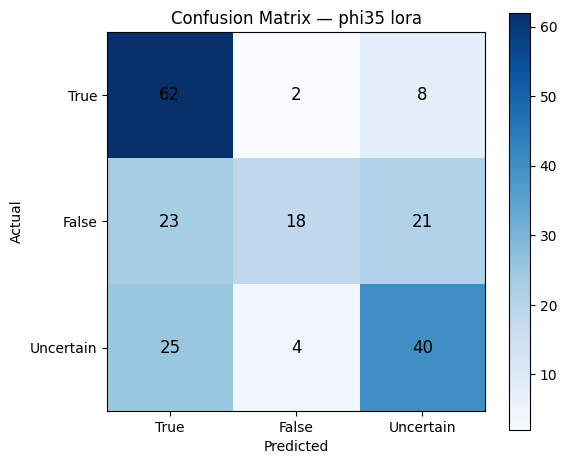

In [ ]:
# Plot confusion matrix heatmap
import numpy as np

labels = ['True', 'False', 'Uncertain']
cm = np.array(metrics['confusion_matrix'])

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap='Blues')
plt.colorbar(im)
ax.set_xticks(range(3)); ax.set_yticks(range(3))
ax.set_xticklabels(labels); ax.set_yticklabels(labels)
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title(f'Confusion Matrix — {MODEL_KEY} {MODE}')
for i in range(3):
    for j in range(3):
        ax.text(j, i, cm[i, j], ha='center', va='center', fontsize=12)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'confusion_matrix.png', dpi=150)
plt.show()

## 3. Deductive consistency


DEDUCTIVE CONSISTENCY (accuracy by premise count):
  Premises 1-2:  Accuracy 72.7%  (8/11)
  Premises 3-4:  Accuracy 64.5%  (20/31)
  Premises 5+:  Accuracy 57.1%  (92/161)


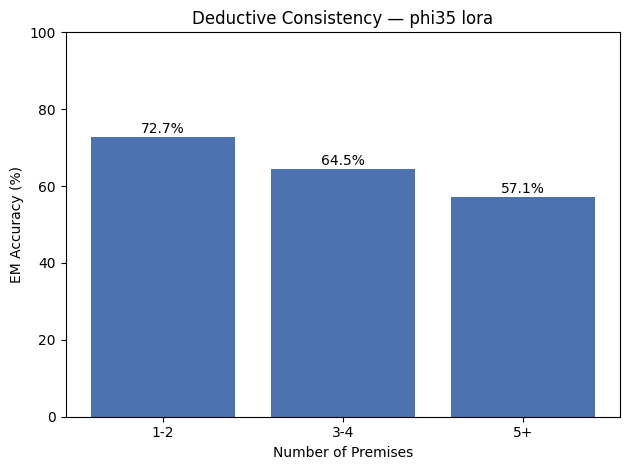

In [ ]:
consistency = build_deductive_consistency(results)

bins = list(consistency.keys())
accs = [consistency[b]['accuracy'] for b in bins]

plt.bar(bins, accs, color='#4C72B0')
plt.ylim(0, 100)
plt.title(f'Deductive Consistency — {MODEL_KEY} {MODE}')
plt.xlabel('Number of Premises')
plt.ylabel('EM Accuracy (%)')
for i, (b, a) in enumerate(zip(bins, accs)):
    plt.text(i, a + 1, f'{a:.1f}%', ha='center')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'deductive_consistency.png', dpi=150)
plt.show()

## 4. Save metrics.json

In [ ]:
from scripts.metrics import run_metrics
run_metrics(str(results_path))
print('Done.')


Experiment: phi35_lora_folio
Model:      microsoft/Phi-3.5-mini-instruct
Prompting:  standard
Accuracy:   59.11330049261084%  (120/203)

CLASSIFICATION REPORT:
              precision    recall  f1-score   support

        True       0.56      0.86      0.68        72
       False       0.75      0.29      0.42        62
   Uncertain       0.58      0.58      0.58        69

    accuracy                           0.59       203
   macro avg       0.63      0.58      0.56       203
weighted avg       0.63      0.59      0.57       203


CONFUSION MATRIX (rows=actual, cols=predicted):
           True  False  Uncertain
True         62      2          8
False        23     18         21
Uncertain    25      4         40

DEDUCTIVE CONSISTENCY (accuracy by premise count):
  Premises 1-2:  Accuracy 72.7%  (8/11)
  Premises 3-4:  Accuracy 64.5%  (20/31)
  Premises 5+:  Accuracy 57.1%  (92/161)

Metrics saved to /content/drive/MyDrive/slm_logic_hardening/outputs/phi35/phi35_lora_folio/metrics